# Zestimatr: Batch Redshift Estimation on 200 Spectra

This tutorial demonstrates running `zestimatr` on a batch of 200 galaxy spectra, then evaluating the predictions with accuracy metrics, calibration diagnostics, and visualizations.

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

import zestimatr
from zestimatr.inference import InferenceDataset

## 1. Load the Data

We have a sample of 200 high-resolution galaxy spectra with ground truth redshifts drawn from the JADES survey.

In [13]:
data_path = "sample_200_spectra.npz"
data = np.load(data_path)

print(f"Number of spectra: {data['flux_high'].shape[0]}")
print(f"Spectrum length:   {data['flux_high'].shape[1]} pixels")
print(f"Redshift range:    [{data['z'].min():.3f}, {data['z'].max():.3f}]")
print(f"Median redshift:   {np.median(data['z']):.3f}")

Number of spectra: 200
Spectrum length:   2500 pixels
Redshift range:    [-0.098, 8.323]
Median redshift:   3.027


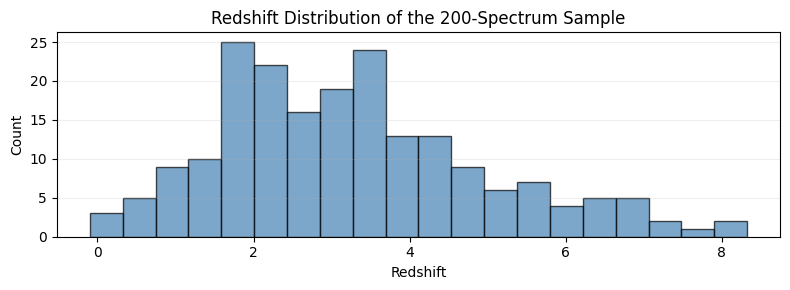

In [14]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(data['z'], bins=20, edgecolor='black', alpha=0.7, color='steelblue')
ax.set_xlabel('Redshift')
ax.set_ylabel('Count')
ax.set_title('Redshift Distribution of the 200-Spectrum Sample')
ax.grid(True, alpha=0.2, axis='y')
plt.tight_layout()
plt.show()

## 2. Load Model and Run Inference

We use `InferenceDataset` to handle the batch loading and per-spectrum normalization automatically.

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load model
zhead, norm_params = zestimatr.load_model(
    "../best_zhead_hires.pth",
    device=device,
)

# Load dataset and run inference
dataset = InferenceDataset(data_path)
dataloader = DataLoader(dataset, batch_size=32, shuffle=False)
predictions = zestimatr.predict_redshifts(zhead, dataloader, norm_params, device)

print(f"\nPredictions for {len(predictions['z_pred'])} spectra")
print(f"Predicted z range: [{predictions['z_pred'].min():.3f}, {predictions['z_pred'].max():.3f}]")
print(f"Median uncertainty: {np.median(predictions['z_uncertainty']):.4f}")

Using device: cuda


Predicting: 100%|██████████| 7/7 [00:00<00:00, 392.90it/s]


Predictions for 200 spectra
Predicted z range: [0.117, 8.460]
Median uncertainty: 0.1468


## 3. Accuracy Metrics

In [16]:
z_pred = predictions['z_pred']
z_true = predictions['z_true']
z_unc = predictions['z_uncertainty']

metrics = zestimatr.compute_metrics(z_pred, z_true)

print("Accuracy Metrics (200 spectra):")
print(f"  MAE:               {metrics['mae']:.4f}")
print(f"  RMSE:              {metrics['rmse']:.4f}")
print(f"  NMAD:              {metrics['nmad']:.4f}")
print(f"  Median |dz|/(1+z): {metrics['median_rel_error']:.4f}")
print(f"  90th pctl |dz|/(1+z): {metrics['p90_rel_error']:.4f}")
print(f"  Outlier rate:      {metrics['outlier_rate']:.1%}  (|dz|/(1+z) > 0.15)")

Accuracy Metrics (200 spectra):
  MAE:               0.1154
  RMSE:              0.2192
  NMAD:              0.0779
  Median |dz|/(1+z): 0.0135
  90th pctl |dz|/(1+z): 0.0789
  Outlier rate:      6.0%  (|dz|/(1+z) > 0.15)


## 4. Calibration Metrics

Are the predicted uncertainties reliable? If the model is well-calibrated, ~68% of predictions should fall within 1 sigma of the true value.

In [17]:
cal = zestimatr.compute_calibration_metrics(z_pred, z_true, z_unc)

print("Calibration Metrics:")
print(f"  Calibration std:    {cal['calibration_std']:.3f}  (ideal = 1.0)")
print(f"  Calibration mean:   {cal['calibration_mean']:.3f}  (ideal = 0.0)")
print(f"  Median uncertainty: {cal['median_uncertainty']:.4f}")
print()
print("  Coverage fractions:")
print(f"    1-sigma: {cal['frac_1sigma']:.1%}  (ideal = 68.3%)")
print(f"    2-sigma: {cal['frac_2sigma']:.1%}  (ideal = 95.4%)")
print(f"    3-sigma: {cal['frac_3sigma']:.1%}  (ideal = 99.7%)")

Calibration Metrics:
  Calibration std:    0.677  (ideal = 1.0)
  Calibration mean:   -0.065  (ideal = 0.0)
  Median uncertainty: 0.1468

  Coverage fractions:
    1-sigma: 90.0%  (ideal = 68.3%)
    2-sigma: 98.5%  (ideal = 95.4%)
    3-sigma: 99.5%  (ideal = 99.7%)


## 5. Visualizations

### Predicted vs True Redshift

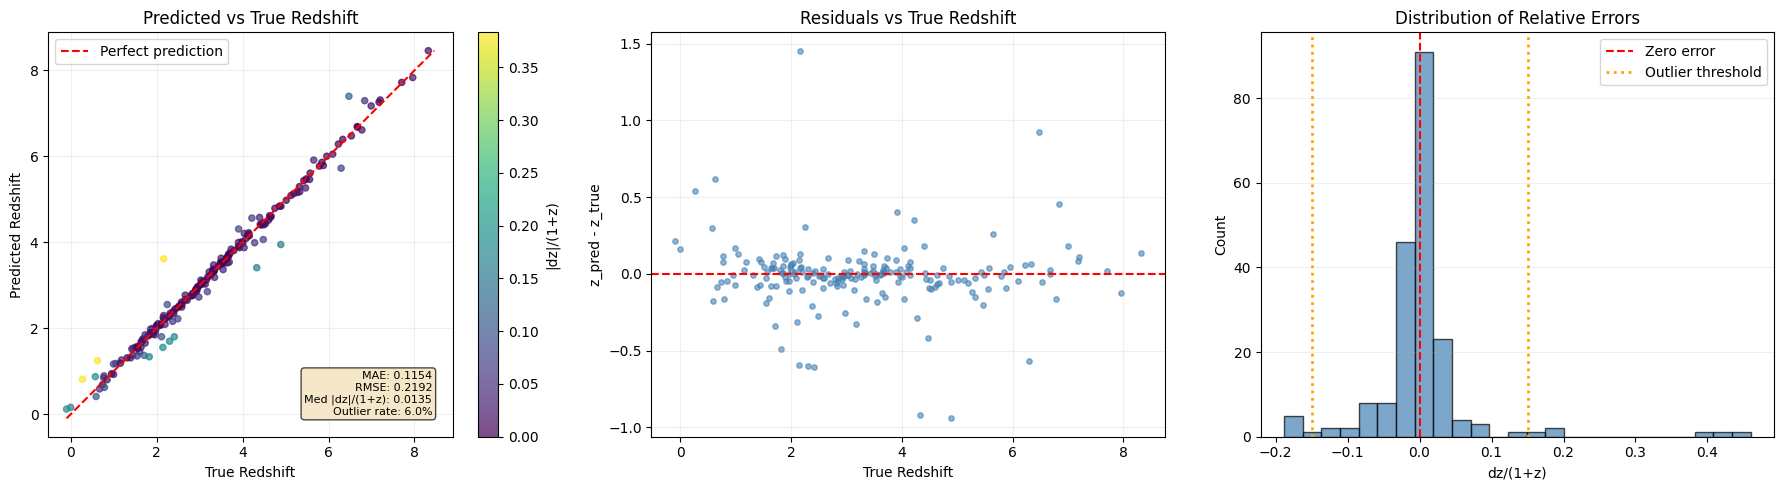

In [18]:
rel_err = np.abs(z_pred - z_true) / (1.0 + np.abs(z_true))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Predicted vs True, colored by relative error
ax = axes[0]
vmax = max(np.percentile(rel_err, 99), 1e-6)
sc = ax.scatter(z_true, z_pred, c=rel_err, s=20, alpha=0.7,
                vmin=0, vmax=vmax, cmap='viridis')
zmin = min(z_true.min(), z_pred.min())
zmax = max(z_true.max(), z_pred.max())
ax.plot([zmin, zmax], [zmin, zmax], 'r--', lw=1.5, label='Perfect prediction')
ax.set_xlabel('True Redshift')
ax.set_ylabel('Predicted Redshift')
ax.set_title('Predicted vs True Redshift')
ax.set_aspect('equal', adjustable='box')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.2)
cb = fig.colorbar(sc, ax=ax)
cb.set_label('|dz|/(1+z)')

metrics_text = (
    f"MAE: {metrics['mae']:.4f}\n"
    f"RMSE: {metrics['rmse']:.4f}\n"
    f"Med |dz|/(1+z): {metrics['median_rel_error']:.4f}\n"
    f"Outlier rate: {metrics['outlier_rate']:.1%}"
)
ax.text(0.95, 0.05, metrics_text, transform=ax.transAxes,
        ha='right', va='bottom',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7),
        fontsize=8)

# Panel 2: Residuals vs true redshift
ax = axes[1]
residuals = z_pred - z_true
ax.scatter(z_true, residuals, s=15, alpha=0.6, c='steelblue')
ax.axhline(0, color='red', linestyle='--', lw=1.5)
ax.set_xlabel('True Redshift')
ax.set_ylabel('z_pred - z_true')
ax.set_title('Residuals vs True Redshift')
ax.grid(True, alpha=0.2)

# Panel 3: Histogram of relative errors
ax = axes[2]
dz_1pz = (z_pred - z_true) / (1.0 + np.abs(z_true))
ax.hist(dz_1pz, bins=25, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(0, color='red', linestyle='--', lw=1.5, label='Zero error')
ax.axvline(0.15, color='orange', linestyle=':', lw=2, label='Outlier threshold')
ax.axvline(-0.15, color='orange', linestyle=':', lw=2)
ax.set_xlabel('dz/(1+z)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Relative Errors')
ax.legend()
ax.grid(True, alpha=0.2, axis='y')

plt.tight_layout()
plt.show()

### Uncertainty Calibration

If the model's uncertainties are well-calibrated, the histogram of normalized residuals `(z_pred - z_true) / sigma` should follow a standard normal distribution N(0, 1).

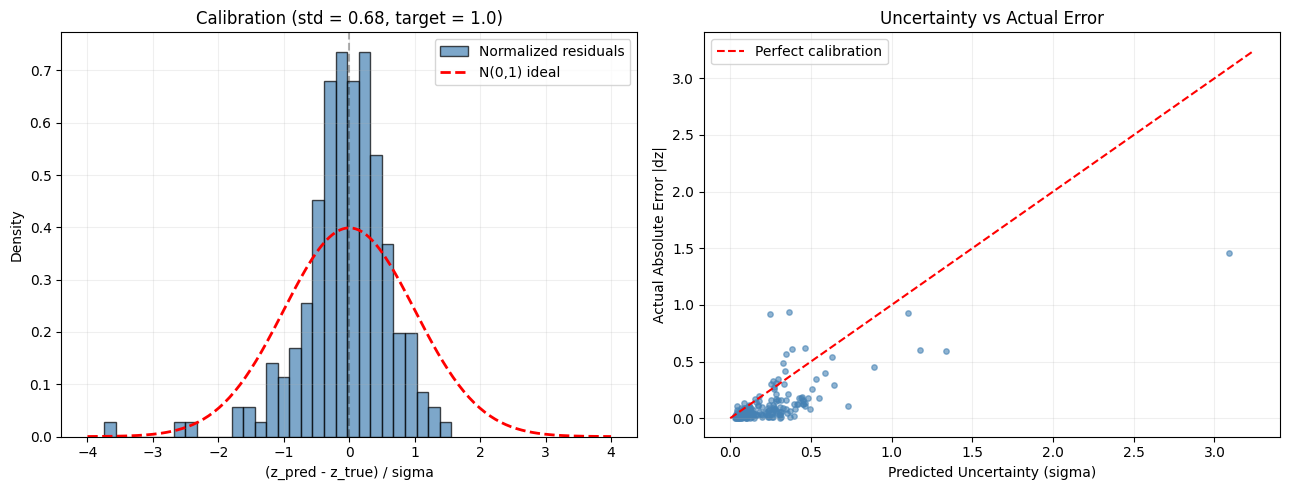

In [19]:
norm_res = (z_pred - z_true) / (z_unc + 1e-12)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Left: normalized residual histogram vs N(0,1)
ax1.hist(norm_res, bins=30, alpha=0.7, edgecolor='black', density=True,
         color='steelblue', label='Normalized residuals')
x_range = np.linspace(-4, 4, 200)
ax1.plot(x_range, 1/np.sqrt(2*np.pi) * np.exp(-0.5*x_range**2),
         'r--', lw=2, label='N(0,1) ideal')
ax1.axvline(0, color='k', linestyle='--', alpha=0.3)
ax1.set_xlabel('(z_pred - z_true) / sigma')
ax1.set_ylabel('Density')
ax1.set_title(f'Calibration (std = {cal["calibration_std"]:.2f}, target = 1.0)')
ax1.legend()
ax1.grid(True, alpha=0.2)

# Right: predicted uncertainty vs actual error
abs_err = np.abs(z_pred - z_true)
ax2.scatter(z_unc, abs_err, s=15, alpha=0.6, c='steelblue')
lim = max(z_unc.max(), abs_err.max()) * 1.05
ax2.plot([0, lim], [0, lim], 'r--', lw=1.5, label='Perfect calibration')
ax2.set_xlabel('Predicted Uncertainty (sigma)')
ax2.set_ylabel('Actual Absolute Error |dz|')
ax2.set_title('Uncertainty vs Actual Error')
ax2.legend()
ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

### Per-Spectrum Results Table

A quick look at the first 10 predictions alongside ground truth.

In [20]:
print(f"{'ID':>6}  {'z_true':>8}  {'z_pred':>8}  {'sigma':>8}  {'|dz|/(1+z)':>10}  {'Outlier?':>8}")
print("-" * 62)
for i in range(min(10, len(z_pred))):
    gal_id = int(data['id'][i])
    zt = z_true[i]
    zp = z_pred[i]
    sig = z_unc[i]
    re = abs(zp - zt) / (1 + abs(zt))
    flag = "  ***" if re > 0.15 else ""
    print(f"{gal_id:>6}  {zt:>8.4f}  {zp:>8.4f}  {sig:>8.4f}  {re:>10.4f}{flag}")

    ID    z_true    z_pred     sigma  |dz|/(1+z)  Outlier?
--------------------------------------------------------------
   587    1.6748    1.7476    0.1430      0.0272
  2065    2.6701    2.6697    0.0497      0.0001
  2836    3.3269    3.3195    0.0438      0.0017
  3222    3.7951    3.8083    0.0791      0.0027
  3499    1.0476    1.1772    0.4189      0.0633
  4030    2.9196    2.8848    0.0382      0.0089
    29    3.1794    2.8508    0.2638      0.0786
    45    2.9812    2.7257    0.2736      0.0642
    56    4.1542    4.1488    0.0968      0.0010
    80    3.9711    3.9574    0.0954      0.0028


### Emission Line Detection

After estimating redshifts, we can detect emission lines in individual spectra.
Let's pick a well-predicted spectrum and visualize its emission lines.

Spectrum index 85 (ID 1770)
z_pred = 6.6795, z_true = 6.6793, |dz|/(1+z) = 0.0000

Detected 8 emission lines


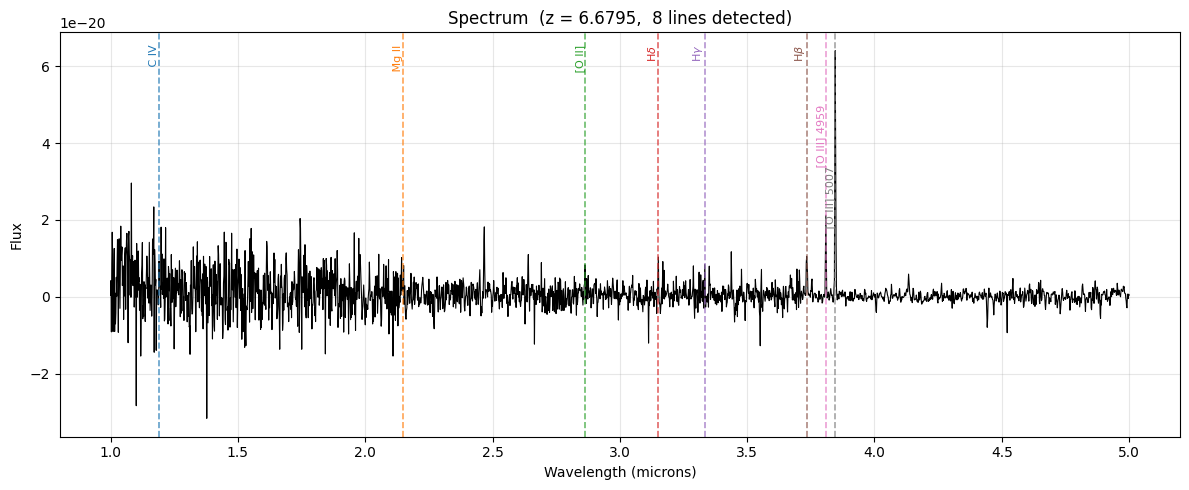

[{'name': 'C IV',
  'rest_wavelength': 0.1549,
  'obs_wavelength': np.float32(1.18956),
  'peak_flux': 2.3408283904882553e-20},
 {'name': 'Mg II',
  'rest_wavelength': 0.27965,
  'obs_wavelength': np.float32(2.1475823),
  'peak_flux': 1.021495844690867e-20},
 {'name': '[O II]',
  'rest_wavelength': 0.3727,
  'obs_wavelength': np.float32(2.862163),
  'peak_flux': 8.344750689414134e-21},
 {'name': 'H$\\delta$',
  'rest_wavelength': 0.41017,
  'obs_wavelength': np.float32(3.1499152),
  'peak_flux': 1.0345790972836545e-20},
 {'name': 'H$\\gamma$',
  'rest_wavelength': 0.43405,
  'obs_wavelength': np.float32(3.3333025),
  'peak_flux': 8.402290729428617e-21},
 {'name': 'H$\\beta$',
  'rest_wavelength': 0.48613,
  'obs_wavelength': np.float32(3.7332528),
  'peak_flux': 1.0530463842447417e-20},
 {'name': '[O III] 4959',
  'rest_wavelength': 0.4959,
  'obs_wavelength': np.float32(3.808282),
  'peak_flux': 6.40814082143469e-20},
 {'name': '[O III] 5007',
  'rest_wavelength': 0.5007,
  'obs_wavel

In [21]:
# Pick a well-predicted spectrum (smallest relative error)
rel_errors = np.abs(z_pred - z_true) / (1.0 + np.abs(z_true))
best_idx = np.argmin(rel_errors)

wl = data['wavelength_high']  # shared wavelength grid
spec_flux = data['flux_high'][best_idx]
spec_z = z_pred[best_idx]

print(f"Spectrum index {best_idx} (ID {int(data['id'][best_idx])})")
print(f"z_pred = {spec_z:.4f}, z_true = {z_true[best_idx]:.4f}, "
      f"|dz|/(1+z) = {rel_errors[best_idx]:.4f}\n")

# Detect and plot emission lines
lines = zestimatr.detect_emission_lines(wl, spec_flux, spec_z)
print(f"Detected {len(lines)} emission lines")
zestimatr.plot_spectrum(wl, spec_flux, z=spec_z, detected_lines=lines)

## 7. Built-in Plotting

`zestimatr` also provides `plot_predictions` for a quick two-panel summary plot.

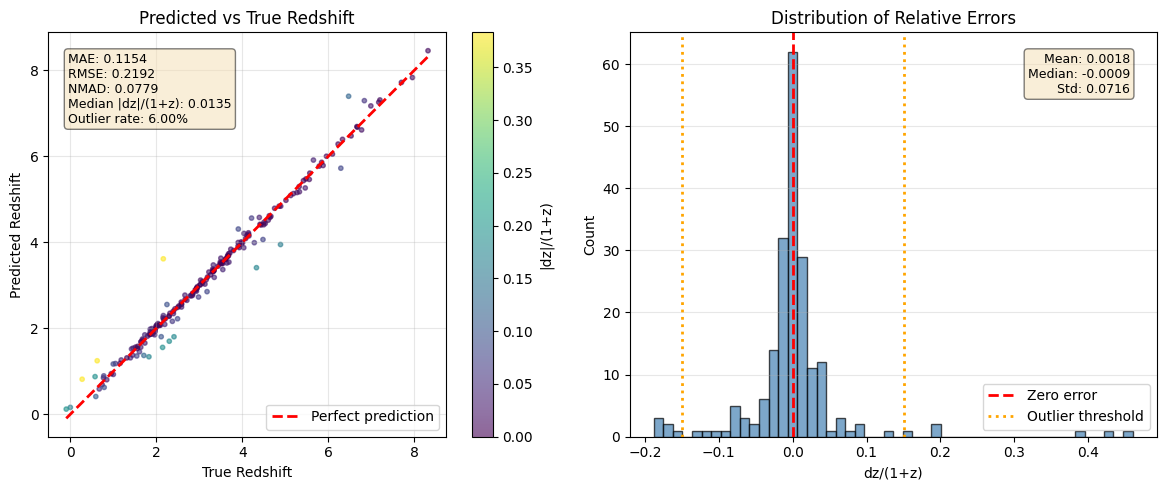

{'mae': 0.11538032540353015,
 'rmse': 0.21917149476016595,
 'median_abs_error': 0.05255347490310669,
 'nmad': 0.07791578189134597,
 'median_rel_error': 0.013455435366721056,
 'p90_rel_error': 0.07893909856102203,
 'outlier_rate': 0.06}

In [22]:
zestimatr.plot_predictions(predictions)

## Summary

We ran `zestimatr` on 200 spectra and evaluated:

- **Accuracy**: MAE, RMSE, NMAD, median relative error, outlier rate
- **Calibration**: whether predicted uncertainties match actual errors
- **Emission lines**: detected and visualized lines for individual spectra using the predicted redshift
- **Visualizations**: pred vs true scatter, residuals, error histograms, calibration diagnostics

These same tools scale to arbitrarily large datasets — just point `InferenceDataset` at your `.npz` file.